# Forecast review

How good is the weekly deaths forecast? A pooled gradient-boosting model is compared against the **naive baseline** ('next weeks = this week') in an expanding-window backtest over 2022–2023. Skill = 1 − MAE(model) / MAE(naive): positive means the model adds value.

In [1]:
import json
import duckdb
import matplotlib.pyplot as plt
import pandas as pd
from covid_pipeline.config import DUCKDB_PATH, FORECAST_METRICS_PATH, FORECAST_PATH, WEEKLY_PATH
from covid_pipeline.warehouse import load_query_pack

plt.rcParams.update({"figure.figsize": (11, 4.5), "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "grid.alpha": 0.3})
con = duckdb.connect(str(DUCKDB_PATH), read_only=True)
Q = load_query_pack()
q = lambda name: con.execute(Q[name]).fetchdf()
report = json.loads(FORECAST_METRICS_PATH.read_text())
bt = report["backtest"]
print(report["method"]); print("Focus countries:", ", ".join(report["focus_countries"].values()))
pd.DataFrame({k: bt[k] for k in ("all_countries", "focus_countries")}).T

log-space change model blended with persistence (weight 0.5)
Focus countries: United States, India, Russia, Italy, France


,mae_deaths,mae_naive_deaths,wape,skill_vs_naive,n
all_countries,33.98,39.01,0.6207,0.1290,84472.0
focus_countries,177.72,192.72,0.2997,0.0778,2760.0


## Skill by horizon
The model's edge is largest 2–6 weeks out. Beyond that, a damped model and persistence perform about equally, which is why the default horizon is 8 weeks.

[Text(0.5, 1.0, 'Skill vs naive baseline, focus countries'),
 Text(0.5, 0, 'horizon (weeks)'),
 Text(0, 0.5, 'skill')]

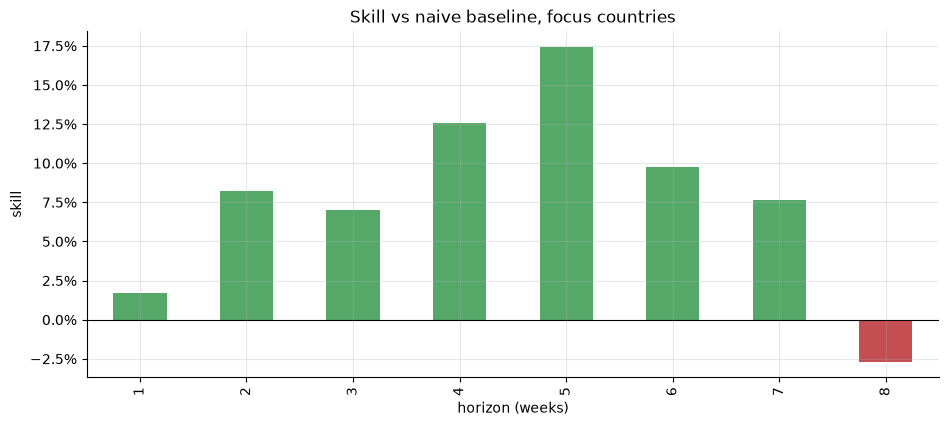

In [2]:
h = pd.DataFrame(bt["by_horizon_focus"]).T
ax = h["skill_vs_naive"].plot.bar(color=["#55A868" if v > 0 else "#C44E52" for v in h["skill_vs_naive"]])
ax.axhline(0, color="black", lw=0.8)
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
ax.set(title="Skill vs naive baseline, focus countries", xlabel="horizon (weeks)", ylabel="skill")

## Skill by country and what drives the model

,skill_vs_naive,wape,mae_deaths,mae_naive_deaths
France,0.2937,0.3345,100.35,142.08
India,-0.0181,1.2774,118.50,116.40
Italy,0.2569,0.3119,96.36,129.68
Russia,0.2262,0.2407,61.13,79.01
United States,-0.0159,0.2545,488.57,480.93


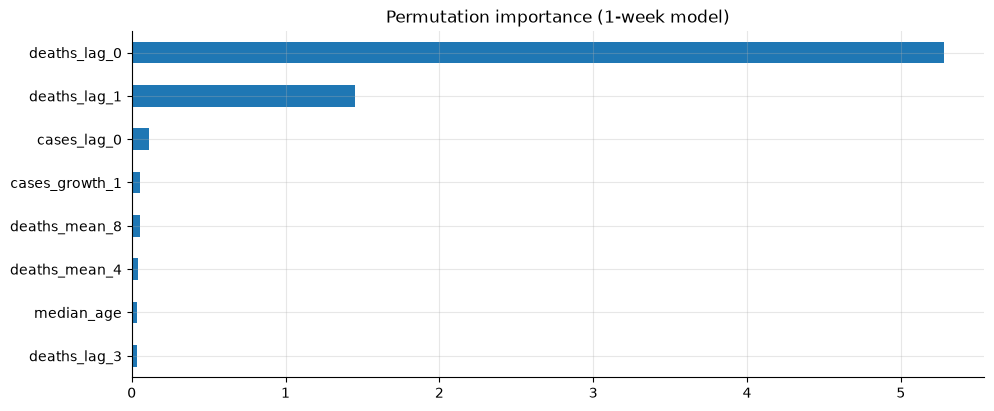

In [3]:
by_country = pd.DataFrame(bt["by_country"]).T.rename(index=report["focus_countries"])
display(by_country[["skill_vs_naive", "wape", "mae_deaths", "mae_naive_deaths"]])
pd.Series(report["permutation_importance_h1"]).head(8).plot.barh(title="Permutation importance (1-week model)").invert_yaxis()

## Outlook: last 26 weeks + forecast with 80% interval

Text(0.5, 1.04, 'Weekly deaths: actual (black) and forecast (blue, 80% interval)')

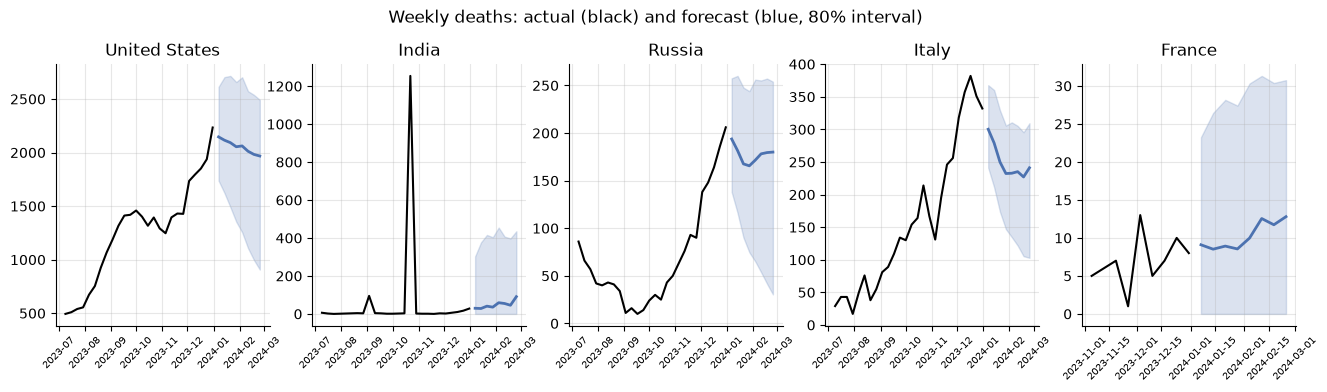

In [4]:
weekly = pd.read_parquet(WEEKLY_PATH)
fc = pd.read_csv(FORECAST_PATH, parse_dates=["origin_date", "target_date"])
focus = fc[fc.is_focus_country]
fig, axes = plt.subplots(1, len(report["focus_countries"]), figsize=(16, 3.4), sharey=False)
for ax, (iso, name) in zip(axes, report["focus_countries"].items()):
    hist = weekly[(weekly.iso_code == iso)].tail(26)
    f = focus[focus.iso_code == iso]
    ax.plot(hist.week_end, hist.new_deaths, color="black", lw=1.5)
    ax.plot(f.target_date, f.predicted_deaths, color="#4C72B0", lw=2)
    ax.fill_between(f.target_date, f.lower_80, f.upper_80, color="#4C72B0", alpha=0.2)
    ax.set_title(name); ax.tick_params(axis="x", labelrotation=45, labelsize=7)
fig.suptitle("Weekly deaths: actual (black) and forecast (blue, 80% interval)", y=1.04)

**Not forecast:** countries whose death reporting had stopped by the forecast origin are skipped, because forecasting 'zero' for them would be fiction.

In [5]:
print(", ".join(report["not_forecast_reporting_stopped"]))

Argentina, Austria, Belarus, Belgium, Brazil, Cambodia, Colombia, Costa Rica, Germany, Japan, Kyrgyzstan, Laos, Mexico, Netherlands, Norway, Paraguay, Peru, Puerto Rico, Serbia, Somalia, South Africa, South Korea, Spain, Turkey, Ukraine, United Kingdom, Uzbekistan
